# Parsing ```PDF``` using UNSTRUCTURE

In [50]:
from unstructured.partition.pdf import partition_pdf
from unstructured.documents.elements import Element, Text, Image, FigureCaption

In [3]:
pdf_file = "D:\\Projects\\Agentic-AI\\langchain-RAG\\docs\\2312.10997v5.pdf"

In [4]:
raw_chunks = partition_pdf(
    filename=pdf_file,
    strategy="hi_res",
    infer_table_structure=True,
    extract_image_block_types=["Image", "Figure", "Table"],
    extract_image_block_to_payload=True,
    chunking_strategy=None,
)

No languages specified, defaulting to English.


preprocessor_config.json:   0%|          | 0.00/274 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/115M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/367 [00:00<?, ?it/s]

In [5]:
raw_chunks

In [6]:
len(raw_chunks)

671

In [ ]:
for chunk in raw_chunks:
    print(f"Type: {type(chunk)}, Text: {chunk.text[:100]}")

In [8]:
raw_chunks[0].to_dict()

{'type': 'UncategorizedText',
 'element_id': '7fcf5fabf2e633e71ad0b4888e6b75aa',
 'text': '4',
 'metadata': {'coordinates': {'points': ((np.float64(79.43055555555554),
     np.float64(1021.0277777777775)),
    (np.float64(79.43055555555554), np.float64(1069.6388888888887)),
    (np.float64(176.65277777777777), np.float64(1069.6388888888887)),
    (np.float64(176.65277777777777), np.float64(1021.0277777777775))),
   'system': 'PixelSpace',
   'layout_width': 2975,
   'layout_height': 3850},
  'last_modified': '2026-04-29T20:26:39',
  'filetype': 'application/pdf',
  'languages': ['eng'],
  'page_number': 1,
  'file_directory': 'D:\\Projects\\Agentic-AI\\langchain-RAG\\docs',
  'filename': '2312.10997v5.pdf'}}

In [ ]:
# data = []

# for el in raw_chunks:
#     data.append(el.to_dict())

# import json

# with open("D:\\Projects\\Agentic-AI\\langchain-RAG\\docs\\chunks.json", "w", encoding="utf-8") as f:
#     json.dump(data, f, indent=2, ensure_ascii=False)

### Image Parsing - Captioning

In [13]:
# Print the indices of chunks that are images
all_image_indices = []
for idx, chunk in enumerate(raw_chunks):
    if isinstance(chunk, Image):
        all_image_indices.append(idx)
        print(idx)

27
40
54
296
360
467


In [15]:
# Print the first image chunk as a dictionary
first_image_chunk_idx = all_image_indices[0]
img_dict=raw_chunks[first_image_chunk_idx].to_dict()

In [25]:
img_dict

{'type': 'Image',
 'element_id': '1b9d81fd8b53f906793ffc6ffa61064c',
 'text': 'Fine-tuning UniMS-RAG PU PE 0 eascessesesssssssassssct hcg [passsssss2a5=ssss5=2= Dual-Feedback-ToD Self-RAG | MK-ToD LM-Indexer InstructRetro RAG_Robust RA-DIT Retrieve-and-Sample GPT-4 SANTA.) ( suGRE RRR Self-Mem UPRISE ~ 2023 =2~-~----------- ChatGPT GPT-3 21-2 teeta Retrieval—Augmented Generation Pre-training Filter-Reranker ICRALM Inference G-Retriever RADA RAPTOR DRAGON-AI CREA-ICL FILCO ARM-RAG PaperQA PRCA 1-PAGER ToC Token-Elimination FABULA KALMV QLM-Doc-ranking KCr KnowledGPT F LLM-R IRCOT PGRA PKG wy SCM4LLMs ITER-RETGEN \\ 5 Co! etro++ LUM Lite P GenRead Augmentation Stage Fine-tuning Pre-training Inference',
 'metadata': {'coordinates': {'points': ((np.float64(425.4347222222222),
     np.float64(272.51700000000017)),
    (np.float64(425.4347222222222), np.float64(1799.6222222222223)),
    (np.float64(2549.51375), np.float64(1799.6222222222223)),
    (np.float64(2549.51375), np.float64(272.5170

In [30]:
my_image_base64=img_dict['metadata']['image_base64']

In [33]:
import base64
from IPython.display import Image, display

def show_base64_image(base64_str):
    img_data = base64.b64decode(base64_str)
    display(Image(data=img_data))


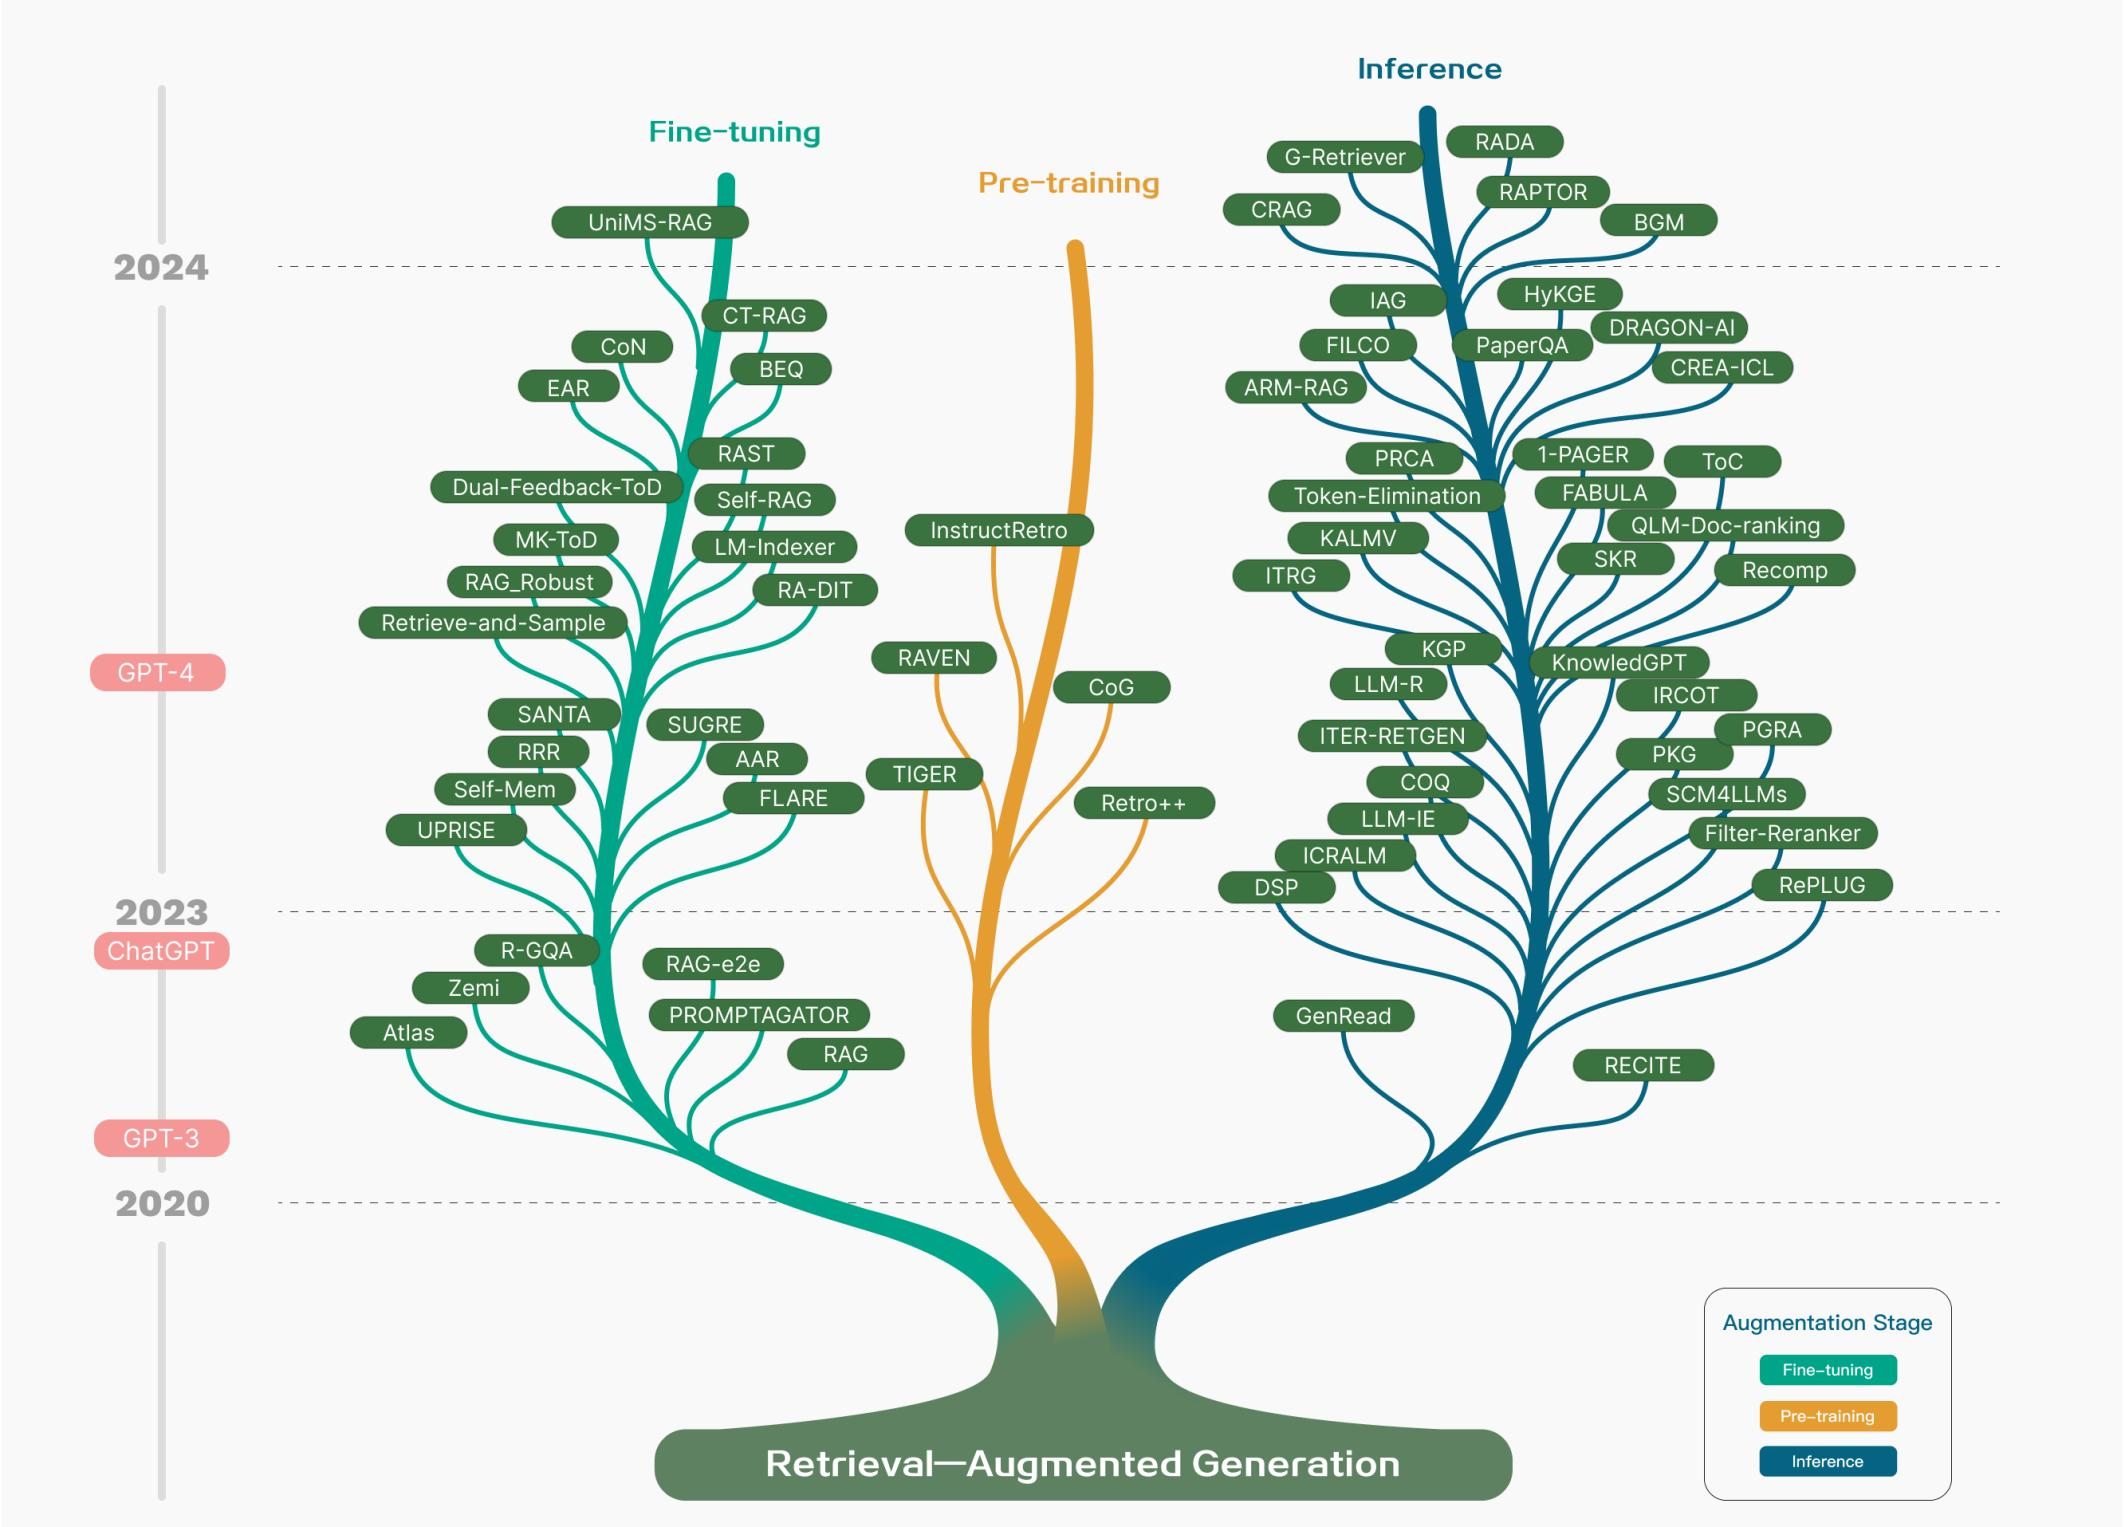

In [34]:
show_base64_image(my_image_base64)

In [32]:
# Print the chunk very next to the first image chunk as a dictionary
first_figure_caption_idx = first_image_chunk_idx + 1
raw_chunks[first_figure_caption_idx].to_dict()

{'type': 'FigureCaption',
 'element_id': 'bd4bc2803805b042c7b9b6085d317bc3',
 'text': 'Fig. 1. Technology tree of RAG research. The stages of involving RAG mainly include pre-training, fine-tuning, and inference. With the emergence of LLMs, research on RAG initially focused on leveraging the powerful in context learning abilities of LLMs, primarily concentrating on the inference stage. Subsequent research has delved deeper, gradually integrating more with the fine-tuning of LLMs. Researchers have also been exploring ways to enhance language models in the pre-training stage through retrieval-augmented techniques.',
 'metadata': {'detection_class_prob': 0.8882073760032654,
  'is_extracted': 'true',
  'coordinates': {'points': ((np.float64(228.6804656982422),
     np.float64(1856.4215911111112)),
    (np.float64(228.6804656982422), np.float64(2025.9241605555555)),
    (np.float64(2758.58935546875), np.float64(2025.9241605555555)),
    (np.float64(2758.58935546875), np.float64(1856.4215911

In [52]:
from unstructured.documents.elements import Image as ImageObj

# Extract images and their captions from the raw chunks
all_images = []

for idx, chunk in enumerate(raw_chunks):

    if isinstance(chunk, ImageObj):

        if idx + 1 < len(raw_chunks) and isinstance(raw_chunks[idx + 1], FigureCaption):
            caption = raw_chunks[idx + 1].text
        else:
            caption = None

        all_images.append({
            "index": idx,
            "caption": caption if caption else "No caption",
            "image_text": chunk.text,
            "base64_image": chunk.metadata.image_base64,
        })


In [54]:
len(all_images)

6

In [53]:
all_images

[{'index': 27,
  'caption': 'Fig. 1. Technology tree of RAG research. The stages of involving RAG mainly include pre-training, fine-tuning, and inference. With the emergence of LLMs, research on RAG initially focused on leveraging the powerful in context learning abilities of LLMs, primarily concentrating on the inference stage. Subsequent research has delved deeper, gradually integrating more with the fine-tuning of LLMs. Researchers have also been exploring ways to enhance language models in the pre-training stage through retrieval-augmented techniques.',
  'image_text': 'Fine-tuning UniMS-RAG PU PE 0 eascessesesssssssassssct hcg [passsssss2a5=ssss5=2= Dual-Feedback-ToD Self-RAG | MK-ToD LM-Indexer InstructRetro RAG_Robust RA-DIT Retrieve-and-Sample GPT-4 SANTA.) ( suGRE RRR Self-Mem UPRISE ~ 2023 =2~-~----------- ChatGPT GPT-3 21-2 teeta Retrieval—Augmented Generation Pre-training Filter-Reranker ICRALM Inference G-Retriever RADA RAPTOR DRAGON-AI CREA-ICL FILCO ARM-RAG PaperQA PRCA 